# Introduction to pytorch

This notebook walks through the core building blocks of PyTorch — from tensors and automatic differentiation, through building and training a neural network, to saving and loading a trained model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Tensors

Tensors are the fundamental data structure in PyTorch, Tensors are just N-dimensional arrays, similar to NumPy arrays but with GPU support and autograd capabilities built in.

In [ ]:
# tensors can be created from numpy

a = np.array([2, 3.5])
t = torch.from_numpy(a)
t

tensor([2.0000, 3.5000], dtype=torch.float64)

In [ ]:
# attributes

print("Shape  :", t.shape)       # torch.Size([3, 4])
print("Dtype  :", t.dtype)       # torch.float32
print("Device :", t.device)      # device cpu or gpu
print("Ndim   :", t.ndim)        # dimension
print("Numel  :", t.numel())     # total number of elements

Shape  : torch.Size([2])
Dtype  : torch.float64
Device : cpu
Ndim   : 1
Numel  : 2


In [ ]:
# tensor operations

x = torch.arange(9)


x_3x3 = x.view(3,3) # contiguous tensor
# x_3x3 = x.reshape(3,3) # safe, performance loss

x_3x3


tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

## Autograd

neural network learns from data by updating parameters using their gradients,PyTorch tracks operations on tensors with `requires_grad=True` and builds a **computational graph** that lets you compute gradients automatically via backpropagation.


In [ ]:
x = torch.tensor(5.)
a = torch.tensor(1., requires_grad=True)
b = torch.tensor(2., requires_grad=True)
c = torch.tensor(3., requires_grad=True)

y = a**2 * x + b * x + c

In [ ]:
a.grad, b.grad, c.grad

(None, None, None)

In [ ]:
y.backward()

In [ ]:
# use backward() to calculate the gradients

a.grad, b.grad, c.grad

(tensor(10.), tensor(5.), tensor(1.))

## toy dataset

create a toy 2D dataset

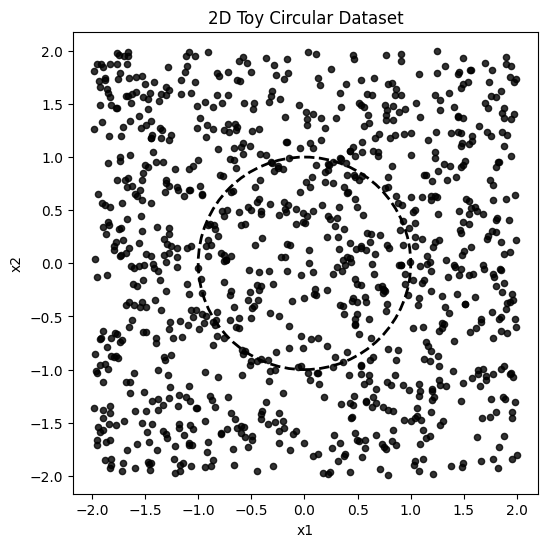

In [ ]:

# Reproducibility
np.random.seed(42)

# Number of samples
n_samples = 1000

# Generate random 2D points
X = np.random.uniform(-2, 2, size=(n_samples, 2))

# Compute radius from center
r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)

# Define labels: inside circle = 0, outside = 1
radius_threshold = 1.0
y = (r > radius_threshold).astype(int)

# Plot
plt.figure(figsize=(6, 6))
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.8)

plt.scatter(X[:, 0], X[:, 1], c='k', s=20, alpha=0.8)

circle = plt.Circle((0, 0), radius_threshold, color='k', fill=False, linestyle='--', linewidth=2)
plt.gca().add_patch(circle)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Toy Circular Dataset")
plt.axis("equal")
plt.show()

In [ ]:
X

array([[-0.50183952,  1.80285723],
       [ 0.92797577,  0.39463394],
       [-1.37592544, -1.37602192],
       ...,
       [ 1.00550034,  0.62782063],
       [ 1.82645848, -1.72416793],
       [-1.77178112, -0.8712517 ]])

In [ ]:

# Convert to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)



### build a model

PyTorch models are defined by subclassing `nn.Module`. You define layers in `__init__` and the forward pass in `forward()`.

nn provides  layers `nn.Linear` and activation function.

In [ ]:

# -----------------------------
#  Define a 2-layer neural network
# -----------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),   # input -> hidden
            nn.ReLU(),         # activation
            nn.Linear(4, 1),    # hidden -> output
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP()

In [ ]:
print(model)

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
  )
)


In [ ]:
for name, param in model.named_parameters():
    print(name, param.shape)

net.0.weight torch.Size([4, 2])
net.0.bias torch.Size([4])
net.2.weight torch.Size([1, 4])
net.2.bias torch.Size([1])


In [ ]:
model.state_dict()

OrderedDict([('net.0.weight',
              tensor([[ 0.5248,  0.2362],
                      [-0.2215, -0.1618],
                      [-0.1573, -0.4531],
                      [-0.6059,  0.2479]])),
             ('net.0.bias', tensor([-0.0468,  0.1911,  0.3190,  0.1518])),
             ('net.2.weight', tensor([[ 0.4654, -0.4392, -0.0530,  0.0576]])),
             ('net.2.bias', tensor([0.4029]))])

### loss

In [ ]:

# -----------------------------
# Loss and optimizer
# -----------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### train the model

A standard training loop in PyTorch has five steps per batch:

1. **Forward pass** — compute predictions
2. **Compute loss**
3. **Zero gradients** — `optimizer.zero_grad()` clear previous grads if any
4. **Backward pass** — `loss.backward()`
5. **Update weights** — `optimizer.step()` update weights

In [ ]:
# -----------------------------
# Training loop
# -----------------------------
n_epochs = 2000
loss_history = []   # <-- store losses

for epoch in range(n_epochs):
    model.train()

    # forward
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # save loss
    loss_history.append(loss.item())

    # logging
    if epoch % 100 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(pred)
            preds = (probs > 0.5).float()
            acc = (preds == y_tensor).float().mean().item()

        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | Accuracy: {acc:.4f}")

Epoch    0 | Loss: 0.5884 | Accuracy: 0.7910
Epoch  100 | Loss: 0.3417 | Accuracy: 0.8030
Epoch  200 | Loss: 0.1801 | Accuracy: 0.9430
Epoch  300 | Loss: 0.1103 | Accuracy: 0.9780
Epoch  400 | Loss: 0.0823 | Accuracy: 0.9790
Epoch  500 | Loss: 0.0677 | Accuracy: 0.9840
Epoch  600 | Loss: 0.0589 | Accuracy: 0.9870
Epoch  700 | Loss: 0.0531 | Accuracy: 0.9870
Epoch  800 | Loss: 0.0487 | Accuracy: 0.9860
Epoch  900 | Loss: 0.0450 | Accuracy: 0.9850
Epoch 1000 | Loss: 0.0423 | Accuracy: 0.9860
Epoch 1100 | Loss: 0.0402 | Accuracy: 0.9860
Epoch 1200 | Loss: 0.0386 | Accuracy: 0.9860
Epoch 1300 | Loss: 0.0373 | Accuracy: 0.9850
Epoch 1400 | Loss: 0.0362 | Accuracy: 0.9850
Epoch 1500 | Loss: 0.0353 | Accuracy: 0.9850
Epoch 1600 | Loss: 0.0346 | Accuracy: 0.9850
Epoch 1700 | Loss: 0.0340 | Accuracy: 0.9850
Epoch 1800 | Loss: 0.0335 | Accuracy: 0.9840
Epoch 1900 | Loss: 0.0331 | Accuracy: 0.9840


## plot loss

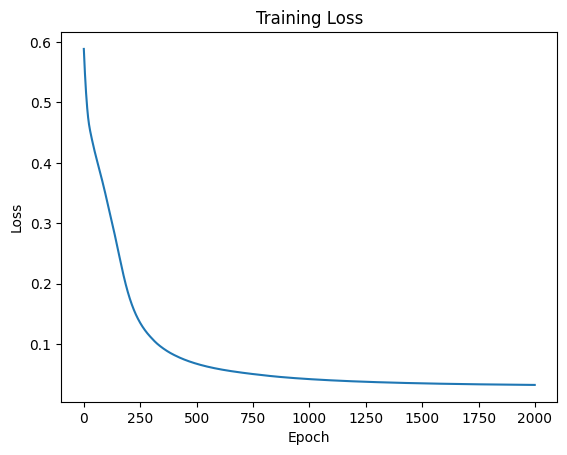

In [ ]:

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## evaluate

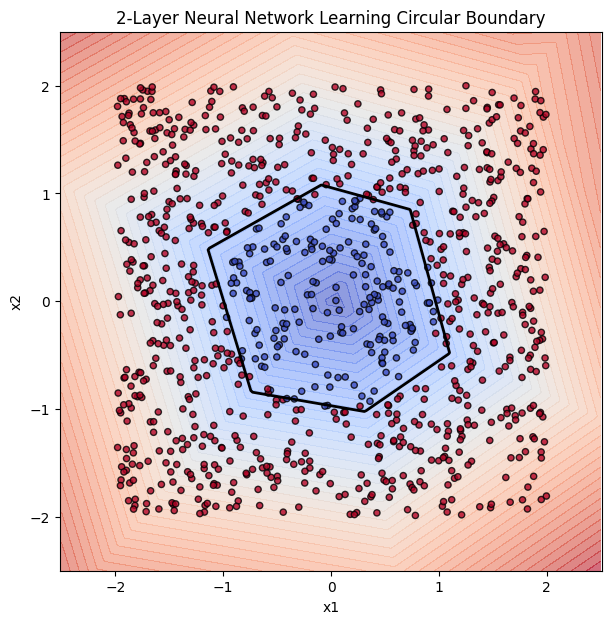

In [ ]:

# -----------------------------
# Plot decision boundary
# -----------------------------
model.eval()

# Create mesh grid
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300),
                     np.linspace(-2.5, 2.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

with torch.no_grad():
    probs = model(grid_tensor).numpy().reshape(xx.shape)

# Plot
plt.figure(figsize=(7, 7))
plt.contourf(xx, yy, probs, levels=50, alpha=0.6, cmap='coolwarm')
plt.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, edgecolor='k', alpha=0.8)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2-Layer Neural Network Learning Circular Boundary")
plt.axis("equal")
plt.show()

### visualize training process

In [51]:
# -----------------------------
# 2. Model
# -----------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 3),
            nn.LeakyReLU(),
            #nn.Sigmoid(),

            # another layer
            #nn.Linear(4, 4),
            #nn.ReLU(),

            # output
            nn.Linear(3, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP()

# -----------------------------
# 3. Training setup
# -----------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# -----------------------------
# 4. Grid for visualization
# -----------------------------
grid_size = 200
x = np.linspace(-2, 2, grid_size)
y_grid = np.linspace(-2, 2, grid_size)
xx, yy = np.meshgrid(x, y_grid)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_torch = torch.tensor(grid, dtype=torch.float32)

# -----------------------------
# 5. Plot function
# -----------------------------
def plot_decision(epoch):
    with torch.no_grad():
        logits = model(grid_torch)
        probs = torch.sigmoid(logits).numpy().reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, probs, levels=50, cmap="coolwarm", alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=10, edgecolor='k')

    plt.title(f"Decision Boundary at Epoch {epoch}")
    plt.axis("equal")
    plt.show()

# -----------------------------
# 6. Training loop with visualization
# -----------------------------
epochs = 3000
for epoch in range(epochs):

    # forward
    logits = model(X_tensor)
    loss = criterion(logits, y_tensor)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # visualize every 200 epochs
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        plot_decision(epoch)

plt.close('all')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
X

array([[-0.50183952,  1.80285723],
       [ 0.92797577,  0.39463394],
       [-1.37592544, -1.37602192],
       ...,
       [ 1.00550034,  0.62782063],
       [ 1.82645848, -1.72416793],
       [-1.77178112, -0.8712517 ]])

In [ ]:
model

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): ReLU()
    (3): Linear(in_features=4, out_features=1, bias=True)
  )
)

IndexError: index 3 is out of bounds for axis 1 with size 3

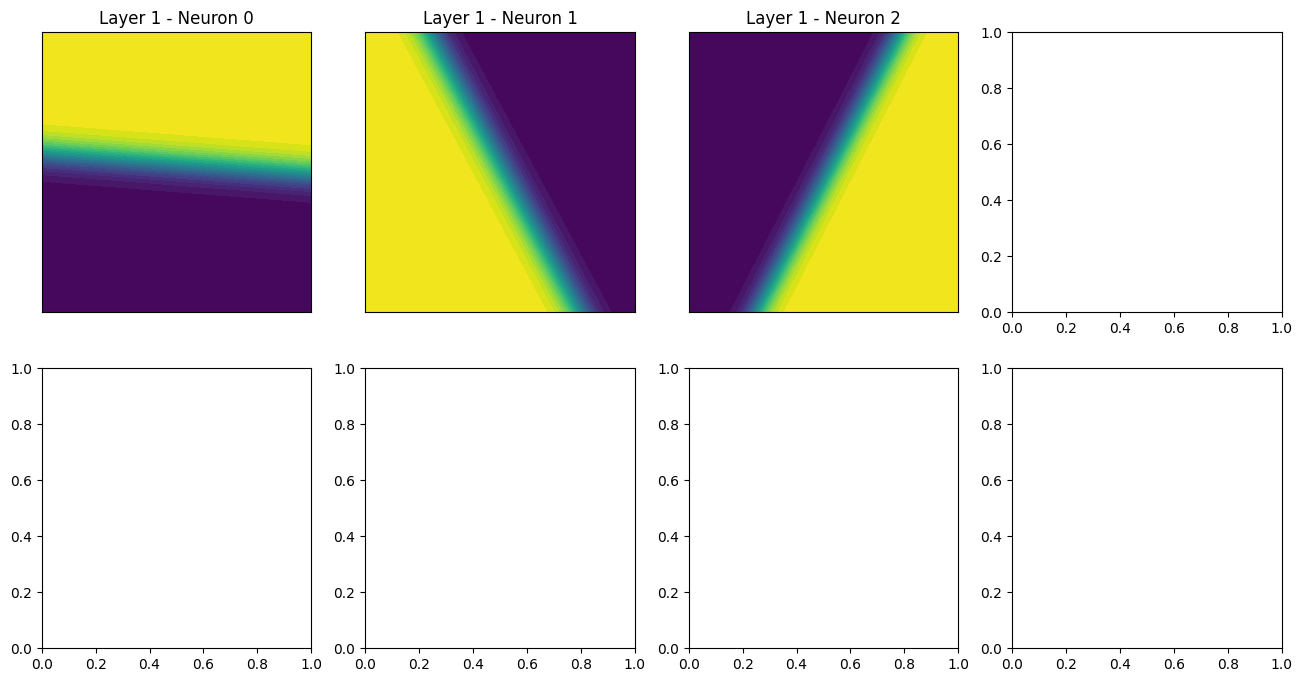

In [50]:

# -----------------------------
# Grid for visualization
# -----------------------------
grid_size = 200
x_grid = np.linspace(-2, 2, grid_size)
y_grid = np.linspace(-2, 2, grid_size)
xx, yy = np.meshgrid(x_grid, y_grid)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_torch = torch.tensor(grid, dtype=torch.float32)

# -----------------------------
# Get activations for both layers
# -----------------------------
def get_activations(model, x):
    with torch.no_grad():
        # Layer 1
        h1 = model.net[0](x)
        h1 = torch.sigmoid(h1)

        # Layer 2
        h2 = model.net[2](h1)
        h2 = torch.relu(h2)

    return h1.numpy(), h2.numpy()

H1, H2 = get_activations(model, grid_torch)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# ---- Layer 1 (4 neurons) ----
for i in range(4):
    ax = axes[0, i]
    activation = H1[:, i].reshape(xx.shape)

    ax.contourf(xx, yy, activation, levels=30, cmap="viridis")
    ax.set_title(f"Layer 1 - Neuron {i}")
    ax.set_xticks([])
    ax.set_yticks([])

# ---- Layer 2 (2 neurons) ----
for i in range(4):
    ax = axes[1, i]
    activation = H2[:, i].reshape(xx.shape)

    ax.contourf(xx, yy, activation, levels=30, cmap="coolwarm")
    ax.set_title(f"Layer 2 - Neuron {i}")
    ax.set_xticks([])
    ax.set_yticks([])

# Turn off unused subplots
for j in range(2, 4):
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

### save and load model

PyTorch offers two main strategies:

| Approach | What's saved | Use case |
|---|---|---|
| **State dict** (recommended) | weights & biases only | resume training, deploy |
| **Full model** | architecture + weights | quick prototyping |

In [ ]:
# ── Save ─────────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "mlp_weights.pth")
print("Model weights saved to mlp_weights.pth")


# ── Load ─────────────────────────────────────────────────────────────────────
# need to re-create the architecture first
loaded_model = SimpleMLP()
loaded_model.load_state_dict(torch.load("mlp_weights.pth", map_location=device))
loaded_model.to(device)
loaded_model.eval()   # always set to eval mode before inference
print("Weights loaded successfully")



Model weights saved to mlp_weights.pth
Weights loaded successfully


### refs

[pytorch](https://pytorch.org)

